In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\USER\Downloads\apple_quality.csv")
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [2]:
df = df.drop(columns=["A_id"],  errors="ignore")
df["Acidity"] = pd.to_numeric(df["Acidity"], errors="coerce")
df = df.dropna()
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   float64
 7   Quality      4000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 281.2+ KB


(None,
        Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness   Acidity  \
 0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840 -0.491590   
 1 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530 -0.722809   
 2 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033  2.621636   
 3 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761  0.790723   
 4  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849  0.501984   
 
   Quality  
 0    good  
 1    good  
 2     bad  
 3    good  
 4    good  )

In [ ]:
# Class balance check
class_counts = df["Quality"].value_counts()
print("Class distribution:")
print(class_counts)
print(f"
Balance ratio: {class_counts.min() / class_counts.max():.3f} (1.0 = perfectly balanced)")

class_counts.plot.bar(figsize=(6, 4), color=["#d9534f", "#5cb85c"], edgecolor="black")
plt.title("Class Distribution (Apple Quality)")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["bad", "good"], rotation=0)
plt.tight_layout()
plt.show()

In [3]:
X = df.drop(columns=["Quality"])
y = df["Quality"].map({"good": 1, "bad": 0})


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 3200 samples
Testing set size: 800 samples


In [4]:
#Logistic Regression pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

In [5]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:, 1])
print(f"Accuracy (Logistic Regression): {accuracy_lr:.2f}")
print(f"ROC-AUC (Logistic Regression): {roc_lr:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy (Logistic Regression): 0.76
ROC-AUC (Logistic Regression): 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76       401
           1       0.76      0.76      0.76       399

    accuracy                           0.76       800
   macro avg       0.76      0.76      0.76       800
weighted avg       0.76      0.76      0.76       800

Confusion Matrix:
 [[303  98]
 [ 97 302]]


In [6]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print(f"Best RF params: {gs_rf.best_params_}")
print(f"Best CV Accuracy: {gs_rf.best_score_:.2f}")

y_pred_rf = gs_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, gs_rf.predict_proba(X_test)[:, 1])
print(f"\nTest Accuracy (Random Forest): {accuracy_rf:.2f}")
print(f"ROC-AUC (Random Forest): {roc_rf:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Best RF params: {'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Best CV Accuracy: 0.88

Test Accuracy (Random Forest): 0.90
ROC-AUC (Random Forest): 0.96

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90       401
           1       0.89      0.90      0.90       399

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.90      0.90      0.90       800

Confusion Matrix:
 [[358  43]
 [ 40 359]]


In [7]:
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', random_state=42, probability=True))
])

param_grid_svm = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.001]
}

gs_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_train, y_train)

print(f"Best SVM params: {gs_svm.best_params_}")
print(f"Best CV Accuracy: {gs_svm.best_score_:.2f}")

y_pred_svm = gs_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, gs_svm.predict_proba(X_test)[:, 1])
print(f"\nTest Accuracy (SVM): {accuracy_svm:.2f}")
print(f"ROC-AUC (SVM): {roc_svm:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Best SVM params: {'clf__C': 100, 'clf__gamma': 'scale'}
Best CV Accuracy: 0.90

Test Accuracy (SVM): 0.92
ROC-AUC (SVM): 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       401
           1       0.93      0.91      0.92       399

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800

Confusion Matrix:
 [[373  28]
 [ 36 363]]


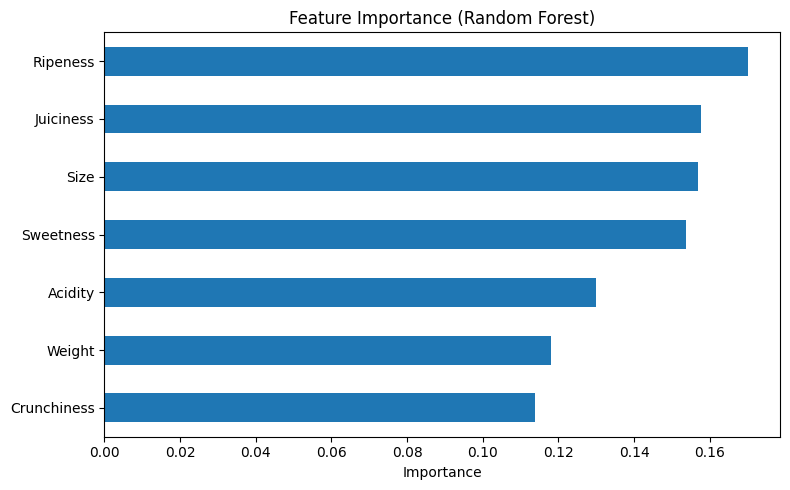

In [8]:
# Feature importance from the best Random Forest
best_rf = gs_rf.best_estimator_.named_steps['clf']
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()

importances.plot.barh(figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [9]:
# Cross-validation comparison across all three models
models = {
    'Logistic Regression': pipe_lr,
    'Random Forest': gs_rf.best_estimator_,
    'SVM': gs_svm.best_estimator_,
}

print(f"{'Model':<25} {'CV Accuracy (meanÂ±std)'}")
print("-" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.3f} Â± {scores.std():.3f}")

Model                     CV Accuracy (meanÂ±std)
--------------------------------------------------
Logistic Regression       0.743 Â± 0.014
Random Forest             0.878 Â± 0.008
SVM                       0.902 Â± 0.005
